# Анализ данных о поездках на самокатах

<Font color='navy'><b><i><u>Цели исследования</font>

<font color='navy'>Анализ данных о поездках и проверка ряда гипотез, необходимых для принятия решений в отношении развития компании, предоставляющей услуги аренды самокатов.

<font color='navy'><b><i><u>Задачи исследования</b></i></u><br>- анализ данных о пользователях и пользовательских предпочтениях<br>- анализ финансовых показателей сервиса<br>- статистическая проверка гипотез

## Обзор данных

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats as st
from scipy.stats import norm
from scipy.stats import binom
from math import factorial
from math import sqrt
import numpy as np
import pandas as pd

**Загрузим первый файл с данными о пользователях**

In [2]:
users = pd.read_csv('C:\\Users\\Svetlana\\DA\\projects\\riders\\users_go.csv')
users.info()
users.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1565 non-null   int64 
 1   name               1565 non-null   object
 2   age                1565 non-null   int64 
 3   city               1565 non-null   object
 4   subscription_type  1565 non-null   object
dtypes: int64(2), object(3)
memory usage: 61.3+ KB


,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra


**Загрузим второй файл с данными о поездках**

In [3]:
rides = pd.read_csv('C:\\Users\\Svetlana\\DA\\projects\\riders\\rides_go.csv')
rides.info()
rides.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   18068 non-null  int64  
 1   distance  18068 non-null  float64
 2   duration  18068 non-null  float64
 3   date      18068 non-null  object 
dtypes: float64(2), int64(1), object(1)
memory usage: 564.8+ KB


,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28


**Загрузим третий файл с данными о тарифах**

In [4]:
plan = pd.read_csv('C:\\Users\\Svetlana\\DA\\projects\\riders\\subscriptions_go.csv')
plan.info()
plan.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_type  2 non-null      object
 1   minute_price       2 non-null      int64 
 2   start_ride_price   2 non-null      int64 
 3   subscription_fee   2 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 196.0+ bytes


,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


***Резюме:***

Для анализа информации о пользователях, их поездках и подписках предоставлено три дата-сета
1. данные о пользователях (id, имя, возраст, город и тип подписки) - 1565 записей, пропусков в данных нет, наименование колонок передает суть представленных в них данных, тип всех данных корректный
2. данные о поездках (id, дистанция, длительность и дата поездки) - 18068 запией, пропусков в данных нет, наименование колонок передает суть представленных в них данных, в одной колонке - дата поездки тип данных некорректный, будет исправлен на этапе предобработки данных, в остальных колонках тип данных корректный
3. информация о подписках (тип подписки, стоимость минуты поездки, стоимость старта и размер ежемесячного платежа) - 2 записи, пропусков в данных нет, наименование колонок передает суть представленных в них данных, тип всех данных корректный.

## Предобработка данных

### Обработка дубликатов

Проверим на наличие дупликатов первый и второй дата-сеты

In [5]:
users.duplicated().sum()

np.int64(31)

In [6]:
users = users.drop_duplicates().reset_index(drop=True)
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1534 entries, 0 to 1533
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1534 non-null   int64 
 1   name               1534 non-null   object
 2   age                1534 non-null   int64 
 3   city               1534 non-null   object
 4   subscription_type  1534 non-null   object
dtypes: int64(2), object(3)
memory usage: 60.1+ KB


In [7]:
rides.duplicated().sum()

np.int64(0)

###  Изменение типа данных

In [8]:
rides['date'] = pd.to_datetime(rides['date'])
rides.dtypes['date']

dtype('<M8[ns]')

###  Объединение данных и создание дополнительных аналитик

Создадим дополнительный столбец - месяц поездки

In [9]:
rides['month'] = rides['date'].dt.month
rides.head()

,user_id,distance,duration,date,month
0,1,4409.919140,25.599769,2021-01-01,1
1,1,2617.592153,15.816871,2021-01-18,1
2,1,754.159807,6.232113,2021-04-20,4
3,1,2694.783254,18.511000,2021-08-11,8
4,1,4028.687306,26.265803,2021-08-28,8


In [10]:
rides['date'].min()

Timestamp('2021-01-01 00:00:00')

In [11]:
rides['date'].max()

Timestamp('2021-12-30 00:00:00')

*Период наблюдений - 1 год с 01.01.2021 по 30.12.2021*

Объединим данные о поездках с данными о пользователях и тарифах, которыми они пользуются

In [12]:
data_all = rides.merge(users, on='user_id', how='outer')
data_all.info()
data_all

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            18068 non-null  int64         
 1   distance           18068 non-null  float64       
 2   duration           18068 non-null  float64       
 3   date               18068 non-null  datetime64[ns]
 4   month              18068 non-null  int32         
 5   name               18068 non-null  object        
 6   age                18068 non-null  int64         
 7   city               18068 non-null  object        
 8   subscription_type  18068 non-null  object        
dtypes: datetime64[ns](1), float64(2), int32(1), int64(2), object(3)
memory usage: 1.2+ MB


,user_id,distance,duration,date,month,name,age,city,subscription_type
0,1,4409.919140,25.599769,2021-01-01,1,Кира,22,Тюмень,ultra
1,1,2617.592153,15.816871,2021-01-18,1,Кира,22,Тюмень,ultra
2,1,754.159807,6.232113,2021-04-20,4,Кира,22,Тюмень,ultra
3,1,2694.783254,18.511000,2021-08-11,8,Кира,22,Тюмень,ultra
4,1,4028.687306,26.265803,2021-08-28,8,Кира,22,Тюмень,ultra
...,...,...,...,...,...,...,...,...,...
18063,1534,3781.098080,19.822962,2021-11-04,11,Альберт,25,Краснодар,free
18064,1534,2840.423057,21.409799,2021-11-16,11,Альберт,25,Краснодар,free
18065,1534,3826.185507,18.435051,2021-11-18,11,Альберт,25,Краснодар,free
18066,1534,2902.308661,16.674362,2021-11-27,11,Альберт,25,Краснодар,free


In [13]:
data = data_all.merge(plan, on='subscription_type', how='outer')
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            18068 non-null  int64         
 1   distance           18068 non-null  float64       
 2   duration           18068 non-null  float64       
 3   date               18068 non-null  datetime64[ns]
 4   month              18068 non-null  int32         
 5   name               18068 non-null  object        
 6   age                18068 non-null  int64         
 7   city               18068 non-null  object        
 8   subscription_type  18068 non-null  object        
 9   minute_price       18068 non-null  int64         
 10  start_ride_price   18068 non-null  int64         
 11  subscription_fee   18068 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int32(1), int64(5), object(3)
memory usage: 1.6+ MB


,user_id,distance,duration,date,month,name,age,city,subscription_type,minute_price,start_ride_price,subscription_fee
0,700,2515.690719,14.944286,2021-01-02,1,Айдар,22,Омск,free,8,50,0
1,700,846.932642,16.234663,2021-02-01,2,Айдар,22,Омск,free,8,50,0
2,700,4004.434142,20.016628,2021-02-04,2,Айдар,22,Омск,free,8,50,0
3,700,1205.911290,9.782872,2021-02-10,2,Айдар,22,Омск,free,8,50,0
4,700,3047.379435,17.427673,2021-02-14,2,Айдар,22,Омск,free,8,50,0


Посмотрим на возможные дубликаты по сумме ключевых параметров:

In [14]:
duplicateRows = data[data.duplicated(['distance', 'duration', 'date', 'city'], keep=False)]
duplicateRows.head()

,user_id,distance,duration,date,month,name,age,city,subscription_type,minute_price,start_ride_price,subscription_fee


***Резюме:***

На этапе подготовки данных 
- выявлены и удалены 31 запись-дубликат в данных о пользователях, в оставшихся дата-сетах дубликаты не выявлены;
- изменен формат данных о дате поездки - приведен к формату - datetime;
- создана дополнительная аналитика date_month - месяц поездки
- объединена информация о пользователях, их поездках и тарифах

## Исследовательский анализ данных

###  Данные о пользователях

####  Города

In [15]:
users.city.value_counts(dropna=False)

city
Пятигорск         219
Екатеринбург      204
Ростов-на-Дону    198
Краснодар         193
Сочи              189
Омск              183
Тюмень            180
Москва            168
Name: count, dtype: int64

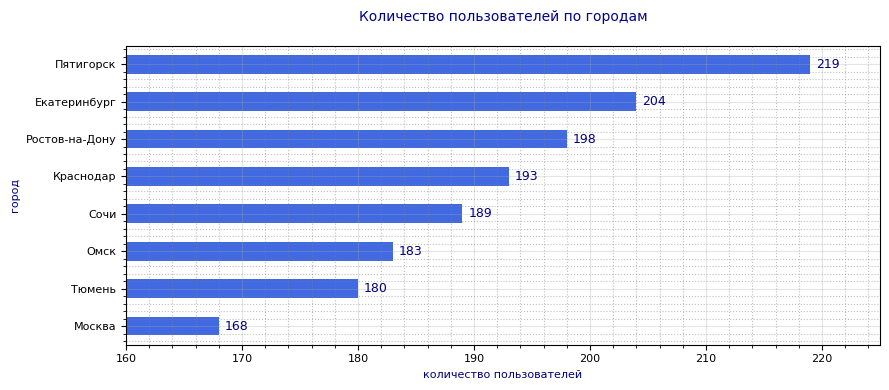

In [16]:
users_city = users['city'].value_counts()

# Построение графика
ax = users_city.sort_values(ascending=True).plot(
    kind='barh', 
    figsize=(9, 4), 
    legend=False, 
    fontsize=8, 
    color='royalblue'
)

# Настройка графика
ax.set_title('Количество пользователей по городам' + "\n", 
             fontsize=10, 
             color='darkblue')
ax.set_xlabel('количество пользователей', fontsize=8, color='navy')
ax.set_ylabel('город', fontsize=8, color='navy')
ax.set_xlim(160, 225)

# Добавляем сетку
ax.minorticks_on()
ax.grid(which='minor', color='grey', ls=':', alpha=0.5)
ax.grid(which='major', color='darkgrey', ls='-', alpha=0.3)

# Добавляем значения
for i, (city, amount) in enumerate(users_city.sort_values(ascending=True).items()):
    ax.text(amount + 0.5, i, str(amount), 
            va='center', fontsize=9, color='navy')

plt.tight_layout()
plt.show()

Из представленного выше графика видно, что
- всего данные содержат информацию о пользователях из 8 городов
- больше всего пользователей в Пятигорске - 219 пользвателей, а меньше всего - в Москве - 168

In [17]:
data_city_grouped = data.pivot_table(index='city', values=('distance', 'duration'), aggfunc=('count','mean'))
data_city_grouped.columns = ['rides_amount','avg_distance', 'dur_count','avg_duration']
data_city_grouped.pop('dur_count')
data_city_grouped['avg_distance'] = round(data_city_grouped['avg_distance'], 2)
data_city_grouped['avg_duration'] = round(data_city_grouped['avg_duration'], 2)
data_city_grouped.sort_values(by='rides_amount', ascending=False)

,rides_amount,avg_distance,avg_duration
city,,,
Пятигорск,2524,3118.68,17.90
Екатеринбург,2461,3110.91,17.82
Ростов-на-Дону,2450,3011.51,17.60
Краснодар,2301,3054.30,17.73
Сочи,2259,3052.96,17.71
Тюмень,2121,3076.24,17.97
Омск,2077,3038.68,17.72
Москва,1875,3101.00,18.03


***Резюме:***

Детализированный анализ данных о поездках, сгруппированных по городам показал, что 
- больше всего поездок осуществляется в Пятигорске - 2524 поездки, где также и самая большая средняя дистанция одной поездки - 3118,68 м.
- меньше всего поездок в Москве - 1875 поездки
- в среднем самые короткие поездки - в Ростове-на-Дону - 3011,51 м.
- средняя длительность поездок различается по городам на десятые доли секунд

####  Подписка

Посмотрим на соотношение пользователей с подпиской и без

1. Соотношение количества пользователей

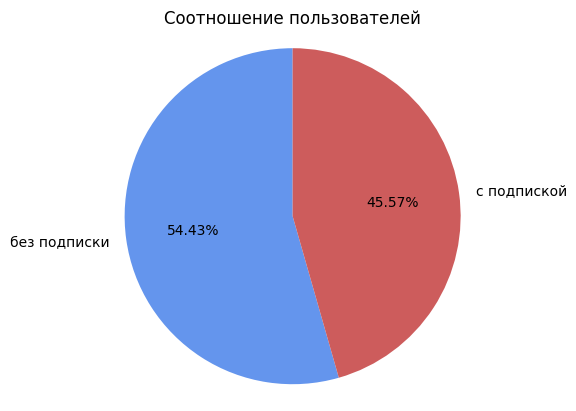

In [18]:
labels = ['без подписки','с подпиской']
values = [users.query('subscription_type == "free"')['subscription_type'].count(), \
          users.query('subscription_type == "ultra"')['subscription_type'].count()]
colors = ['cornflowerblue','indianred']
plt.pie(values, labels=labels, colors=colors, autopct='%1.2f%%', startangle=90)
plt.title('Соотношение пользователей')
plt.axis('equal')
plt.show()


2. Соотношение количества поездок

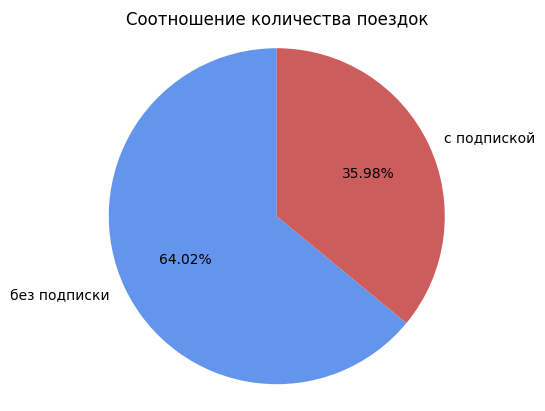

In [19]:
labels = ['без подписки','с подпиской']
values = [data.query('subscription_type == "free"')['subscription_type'].count(), \
          data.query('subscription_type == "ultra"')['subscription_type'].count()]
colors = ['cornflowerblue','indianred']
plt.pie(values, labels=labels, colors=colors, autopct='%1.2f%%', startangle=90)
plt.title('Соотношение количества поездок')
plt.axis('equal')
plt.show()

3. Посмотрим на распределение пользователей с/без подписки по городам

In [20]:
users_city_subs = users.pivot_table(index='city', columns='subscription_type', values='user_id', aggfunc='count')
users_city_subs.columns = ['free', 'ultra']
users_city_subs['free_share'] = round((users_city_subs['free'] / (users_city_subs['free'] + users_city_subs['ultra'])* 100), 2) 
users_city_subs['ultra_share'] = round((users_city_subs['ultra'] / (users_city_subs['free'] + users_city_subs['ultra']) * 100), 2) 
users_city_subs.sort_values(by='ultra')

,free,ultra,free_share,ultra_share
city,,,,
Краснодар,112,81,58.03,41.97
Тюмень,98,82,54.44,45.56
Москва,84,84,50.00,50.00
Сочи,103,86,54.50,45.50
Ростов-на-Дону,109,89,55.05,44.95
Омск,92,91,50.27,49.73
Екатеринбург,112,92,54.90,45.10
Пятигорск,125,94,57.08,42.92


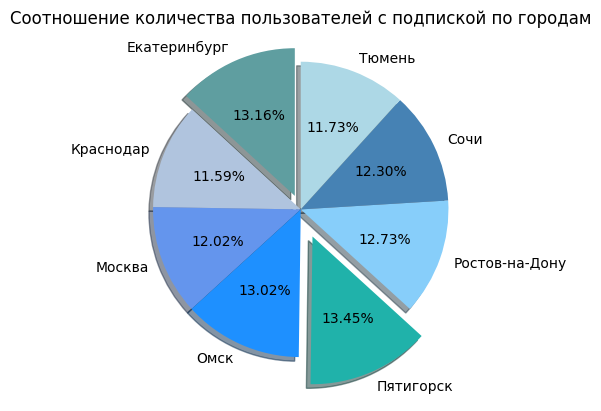

In [21]:
labels = users_city_subs.index
values = users_city_subs['ultra']
colors = ['cadetblue', 'lightsteelblue','cornflowerblue', 'dodgerblue', 'lightseagreen', \
          'lightskyblue', 'steelblue', 'lightblue']
explode = [0.1,0,0,0,0.2,0,0,0]
plt.pie(values, labels=labels, colors=colors, explode=explode, shadow=True, autopct='%1.2f%%', startangle=90)
plt.title('Соотношение количества пользователей с подпиской по городам')
plt.axis('equal')
plt.show()

4. Соотношение количества поездок с/без подписки по городам

In [22]:
data.pivot_table(index=('subscription_type', 'city'), values='user_id', aggfunc='count')

user_id
subscription_type city                   
free              Екатеринбург       1585
                  Краснодар          1521
                  Москва             1175
                  Омск               1250
                  Пятигорск          1672
                  Ростов-на-Дону     1565
                  Сочи               1446
                  Тюмень             1354
ultra             Екатеринбург        876
                  Краснодар           780
                  Москва              700
                  Омск                827
                  Пятигорск           852
                  Ростов-на-Дону      885
                  Сочи                813
                  Тюмень              767

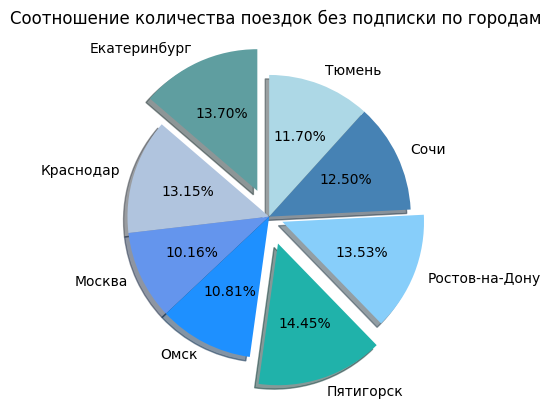

In [23]:
# labels= ['Екатеринбург', 'Краснодар', 'Москва', 'Омск', 'Пятигорск','Ростов-на-Дону', 'Сочи', 'Тюмень']
values = data.query('subscription_type == "free"').groupby('city')['user_id'].count()
colors = ['cadetblue', 'lightsteelblue','cornflowerblue', 'dodgerblue', 'lightseagreen', \
          'lightskyblue', 'steelblue', 'lightblue']
explode = [0.2,0,0,0,0.2,0.1,0,0]
plt.pie(values, labels=labels, colors=colors, explode=explode, shadow=True, autopct='%1.2f%%', startangle=90)
plt.title('Соотношение количества поездок без подписки по городам')
plt.axis('equal')
plt.show()

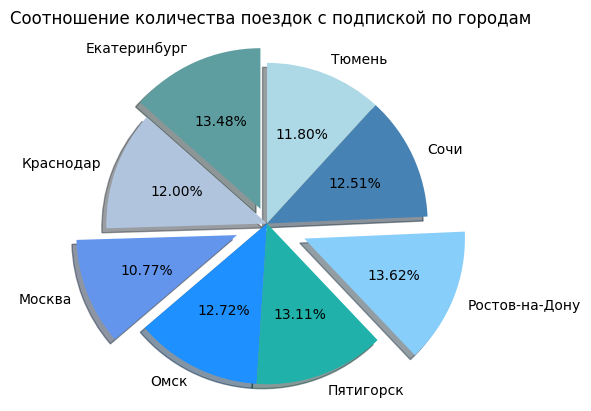

In [24]:
labels= ['Екатеринбург', 'Краснодар', 'Москва', 'Омск', 'Пятигорск','Ростов-на-Дону', 'Сочи', 'Тюмень']
values = data.query('subscription_type == "ultra"').groupby('city')['user_id'].count()
colors = ['cadetblue', 'lightsteelblue','cornflowerblue', 'dodgerblue', 'lightseagreen', \
          'lightskyblue', 'steelblue', 'lightblue']
explode = [0.1,0,0.2,0,0,0.25,0,0]
plt.pie(values, labels=labels, colors=colors, explode=explode, shadow=True, autopct='%1.2f%%', startangle=90)
plt.title('Соотношение количества поездок с подпиской по городам')
plt.axis('equal')
plt.show()

***Резюме:***

*Анализ данных о подписке показал, что*
- общее соотношение пользователей без и с подпиской - 54.43 и 45.57%% 
- общее соотношение поездок без подписки и с подпиской - 64.02 и 35.98%%
- в Краснодаре самое высокое соотношение доли пользователей без подписки к пользователям с подпиской 58.03% к 41.97%
- в Москве самое высокое соотношение доли пользователей с подпиской к доле пользователей без подписки 50 х 50 
- больше всего пользователей сервиса в Пятигорске как по подписке - 94 (13.45% всех пользователей сервиса), так и без подписки - 125 (14.97% всех пользователей сервиса)
- меньше всего пользователей с подпиской в Тюмени - 82 (11.73% всех пользователей сервиса)
- меньше всего пользователей без подписки в Москве - 84 (10.06% всех пользователей сервиса)
- больше всего по подписке сделано поездок в Ростове-на-Дону - 885 (13.62% всех поездок), меньше всего по подписке ездиют в Москве - 700 поездок (10.77% всех поездок)
- больше всего без подписки сделано поездок в Пятигорске - 1672 (14.45% всех поездок), меньше всего по подписке ездиют в Москве - 1175 поездок (10.16% всех поездок)

####  Возраст пользователей

In [25]:
users['age'].describe(percentiles=[0.15, 0.5, 0.85])

count    1534.000000
mean       24.903520
std         4.572367
min        12.000000
15%        20.000000
50%        25.000000
85%        30.000000
max        43.000000
Name: age, dtype: float64

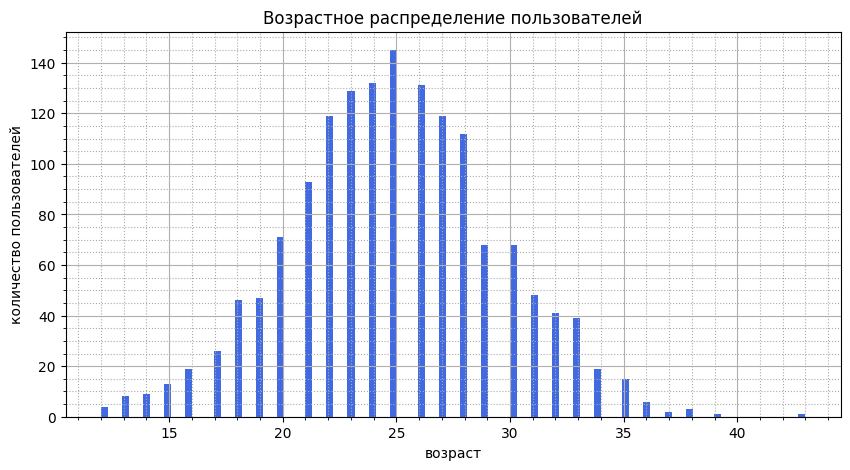

In [26]:
users['age'].hist(bins=100,range=(12, 43), figsize=(10,5), color='royalblue')
plt.title("Возрастное распределение пользователей")
plt.xlabel("возраст")
plt.ylabel("количество пользователей")
plt.minorticks_on()
plt.grid(which='minor', color='#aaa', ls=':')

In [27]:
data['age'].describe(percentiles=[0.15, 0.5, 0.85])

count    18068.000000
mean        24.893071
std          4.582216
min         12.000000
15%         20.000000
50%         25.000000
85%         30.000000
max         43.000000
Name: age, dtype: float64

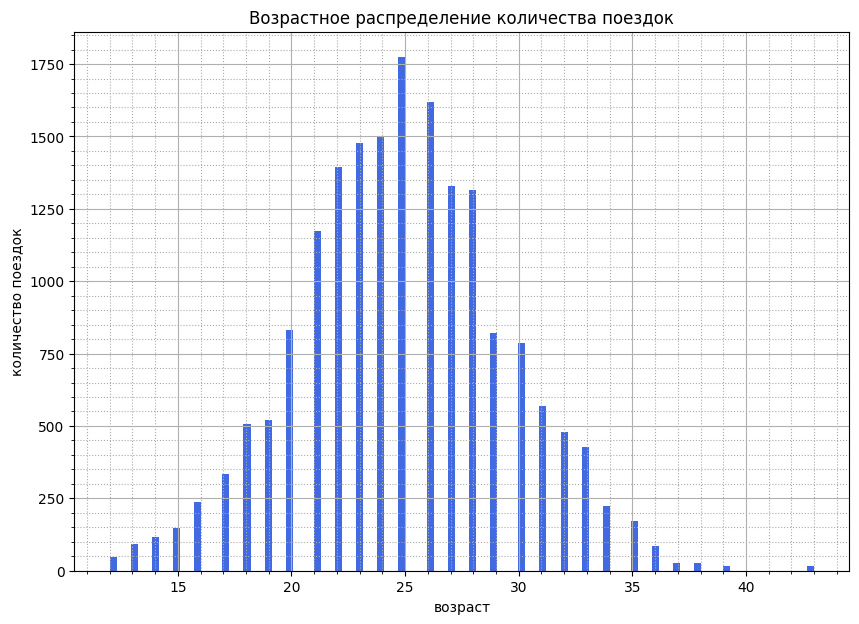

In [28]:
data['age'].hist(bins=100,range=(12, 43), figsize=(10,7), color='royalblue')
plt.title("Возрастное распределение количества поездок")
plt.xlabel("возраст")
plt.ylabel("количество поездок")
plt.minorticks_on()
plt.grid(which='minor', color='#aaa', ls=':')

In [29]:
data.query('20 < age < 30 and subscription_type == "free"')['user_id'].count()

np.int64(8243)

In [30]:
data.query('20 < age < 30 and subscription_type == "ultra"')['user_id'].count()

np.int64(4157)

***Резюме:***

*Из приведенных выше таблиц и графиков видно, что:*
- средний и медианный возраст пользователей практически совпадает и составляет 25 лет
- 70% пользователей - пользователи в возрасте от 20 до 30 лет
- среди этой категории 66,5% не пользуются подпиской

####   Поездки

##### Длина одной поездки

In [31]:
data['distance'].describe(percentiles=[0.15, 0.5, 0.85])

count    18068.000000
mean      3070.659976
std       1116.831209
min          0.855683
15%       2142.037255
50%       3133.609994
85%       4164.220152
max       7211.007745
Name: distance, dtype: float64

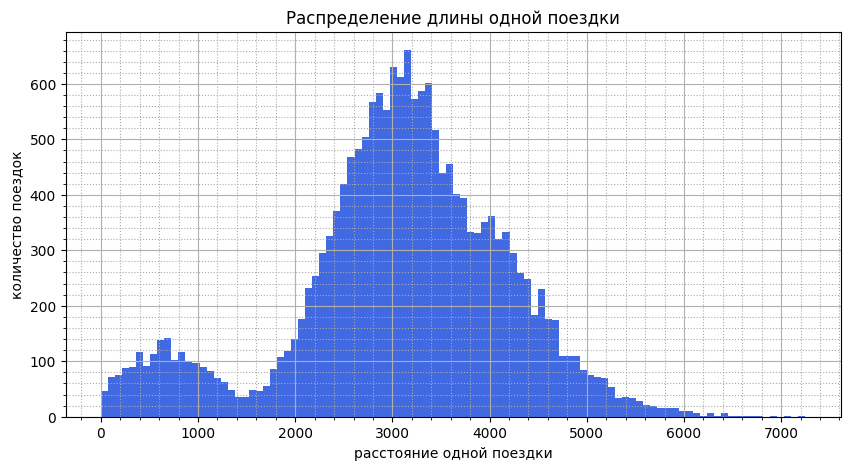

In [32]:
data['distance'].hist(bins=100,range=(0, 7250), figsize=(10,5), color='royalblue')
plt.title('Распределение длины одной поездки')
plt.xlabel('расстояние одной поездки')
plt.ylabel('количество поездок')
plt.minorticks_on()
plt.grid(which='minor', color='#aaa', ls=':')

In [33]:
data.query('distance <= 1500')['user_id'].count()

np.int64(1796)

***Резюме:***

*Статистика поездок и график распределения расстояний, на которые пользователи брали самокаты видно, что*
- 70% поездок осуществляется на расстояние от 2,1 до 4,2 км., 
- медианное значение составляет 3,1 км.
- максимальная длина одной поездки составляет 7,2 км.
- на графике и по срезу видно 1й "горб" с пиком поездок в районе 650-700 м для достаточно большого (1796 - 9,9%) количества поездок на расстояние до 1,5 км., которое к 1,5 км. сокращается, с последующим уже нормальным распределением количества поездок от расстояния

Такое распределение называется бимодальным - распределение с двумя пиками. Возникло оно скорее всего из-за наличия двух типовых дальностей поездок - поездки на небольшую дистанцию около 800 м и поездки на дистанцию около 3х км

##### Продолжительность одной поездки

In [34]:
data['duration'].describe(percentiles=[0.15, 0.5, 0.85])

count    18068.000000
mean        17.805011
std          6.091051
min          0.500000
15%         11.618539
50%         17.678395
85%         24.087761
max         40.823963
Name: duration, dtype: float64

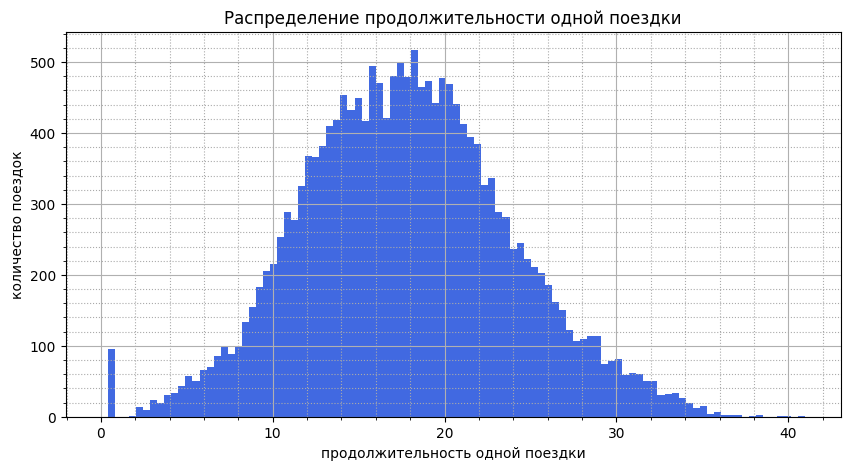

In [35]:
data['duration'].hist(bins=100,range=(0, 41), figsize=(10,5), color='royalblue')
plt.title('Распределение продолжительности одной поездки')
plt.xlabel('продолжительность одной поездки')
plt.ylabel('количество поездок')
plt.minorticks_on()
plt.grid(which='minor', color='#aaa', ls=':')

80% пользователей берут самокаты на время от 12 до 25 минут (с учетом округления в большую сторону). В среднем поездка длится 18 минут. На гистограмме также виден 1 выброс с длительностью поездки в 1 минуту.

In [36]:
data.query('duration <= 1').groupby('city')['user_id'].count()

city
Екатеринбург       9
Краснодар         10
Москва            14
Омск              11
Пятигорск         13
Ростов-на-Дону    17
Сочи              11
Тюмень            10
Name: user_id, dtype: int64

In [37]:
data_dur_zero = data.query('duration <=1 and distance !=0')
data_dur_zero

,user_id,distance,duration,date,month,name,age,city,subscription_type,minute_price,start_ride_price,subscription_fee
31,701,4196.445201,0.5,2021-08-31,8,Иван,31,Екатеринбург,free,8,50,0
70,704,4830.824371,0.5,2021-10-14,10,Мирон,29,Ростов-на-Дону,free,8,50,0
180,712,4684.004397,0.5,2021-03-04,3,Дарья,28,Москва,free,8,50,0
195,713,5215.642710,0.5,2021-02-25,2,Святослав,30,Краснодар,free,8,50,0
268,718,5197.436649,0.5,2021-02-11,2,Владислава,31,Москва,free,8,50,0
...,...,...,...,...,...,...,...,...,...,...,...,...
10504,1460,5531.335845,0.5,2021-01-19,1,Жанна,27,Пятигорск,free,8,50,0
10742,1477,6724.932981,0.5,2021-01-12,1,Ян,17,Сочи,free,8,50,0
10814,1483,4445.481070,0.5,2021-03-06,3,Роберт,26,Екатеринбург,free,8,50,0
11005,1496,5722.551787,0.5,2021-02-14,2,Яна,19,Москва,free,8,50,0


In [38]:
data_dur_zero['subscription_type'].unique()

array(['free'], dtype=object)

С высокой долей вероятности - это не поездки, а ошибки пользователей при разблокировке самоката со стоянки. С учетом того, что процент подобных случаев незначителен - 0,5%, удалим эти записи.

In [39]:
data = data.query('duration >= 1')
data['duration'].describe(percentiles=[0.15, 0.5, 0.85])

count    17973.000000
mean        17.896480
std          5.975424
min          2.035632
15%         11.728225
50%         17.714122
85%         24.107074
max         40.823963
Name: duration, dtype: float64

***Резюме:***

*Статистика поездок и график распределения длительности поездок показали*
- незначительный выброс - 0,05% - поездки длительностью менее 1 минуты, записи о которых были удалены 
- после удаления 95 записей статистика поездок отражает, что 
     - 70% поездок длится от 12 до 25 минут 
     - медианное значение составляет 18 минут
     - минимальная длительность поездки - 2 минуты
     - максимальная длительность поездки - 41 минута

## Данные по типу подписки

Разобьем основной массив данных на два: данные о пользователях с подпиской и данные о пользователях без подписки.

### Пользователи без подписки

In [40]:
data_free = data.query('subscription_type == "free"')
data_free.shape[0]

11473

#### Длина одной поездки для пользователей без подписки

In [41]:
data_free['distance'].describe(percentiles=[0.15, 0.5, 0.85])

count    11473.000000
mean      3028.374239
std       1235.541051
min          0.855683
15%       1933.656725
50%       3102.083025
85%       4268.157741
max       7066.003772
Name: distance, dtype: float64

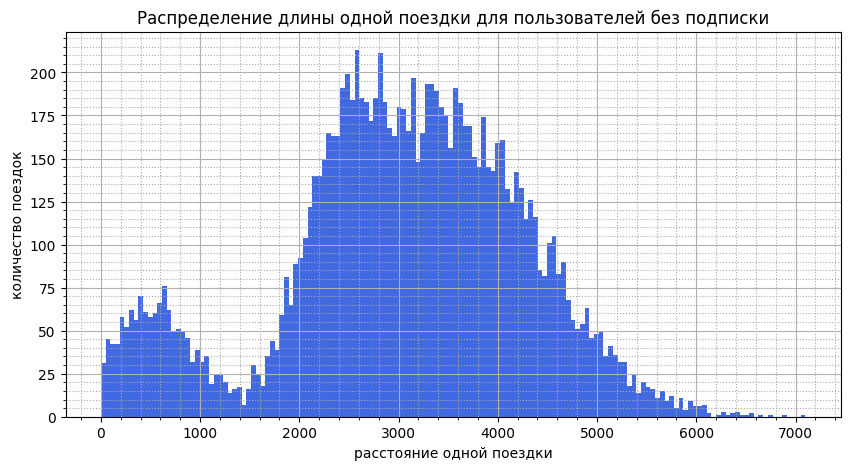

In [42]:
data_free['distance'].hist(bins=150,range=(0, 7100), figsize=(10,5), color='royalblue')
plt.title('Распределение длины одной поездки для пользователей без подписки')
plt.xlabel('расстояние одной поездки')
plt.ylabel('количество поездок')
plt.minorticks_on()
plt.grid(which='minor', color='#aaa', ls=':')

In [43]:
data_free.query('distance <= 1500')['user_id'].count()

np.int64(1328)

***Резюме:***

*Для пользователей без подписки:*
- средняя длина поездки - 3,1 км
- максимальное расстояние - 7,1 км
- на графике и по срезу видно 1й "горб" с пиком поездок в районе 650 м для достаточно большого (1328 - 11.6%) количества поездок на расстояние до 1,5 км., которое к 1,5 км. сокращается, с последующим уже нормальным распределением количества поездок от расстояния
- 70% пользователей без подписки совершают поездки на расстояние от 1,9 до 4,3 км.

#### Длительность одной поездки для пользователей без подписки

In [44]:
data_free['duration'].describe(percentiles=[0.15, 0.5, 0.85])

count    11473.000000
mean        17.530771
std          6.162609
min          2.035632
15%         11.031426
50%         17.383807
85%         23.999011
max         34.948498
Name: duration, dtype: float64

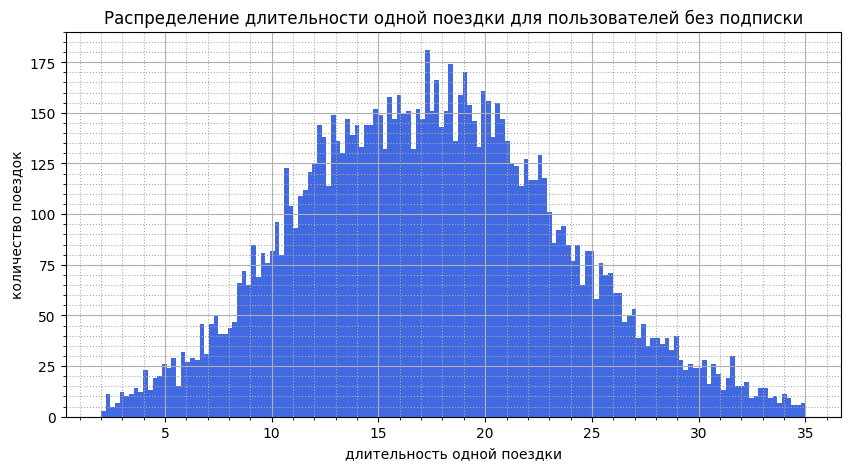

In [45]:
data_free['duration'].hist(bins=150,range=(2, 35), figsize=(10,5), color='royalblue')
plt.title('Распределение длительности одной поездки для пользователей без подписки')
plt.xlabel('длительность одной поездки')
plt.ylabel('количество поездок')
plt.minorticks_on()
plt.grid(which='minor', color='#aaa', ls=':')

***Резюме:***

Для пользователей без подписки:
- средняя длительность поездки - 18 минут
- максимальная длительность - 35 минут
- 70% поездок длится от 12 до 24 минут

### Пользователи с подпиской

In [46]:
data_ultra = data.query('subscription_type == "ultra"')
data_ultra.shape[0]

6500

#### Длина одной поездки для пользователей с подпиской

In [47]:
data_ultra['distance'].describe(percentiles=[0.15, 0.5, 0.85])

count    6500.000000
mean     3115.445388
std       836.895330
min       244.210438
15%      2558.472175
50%      3148.637229
85%      3942.972765
max      5699.769662
Name: distance, dtype: float64

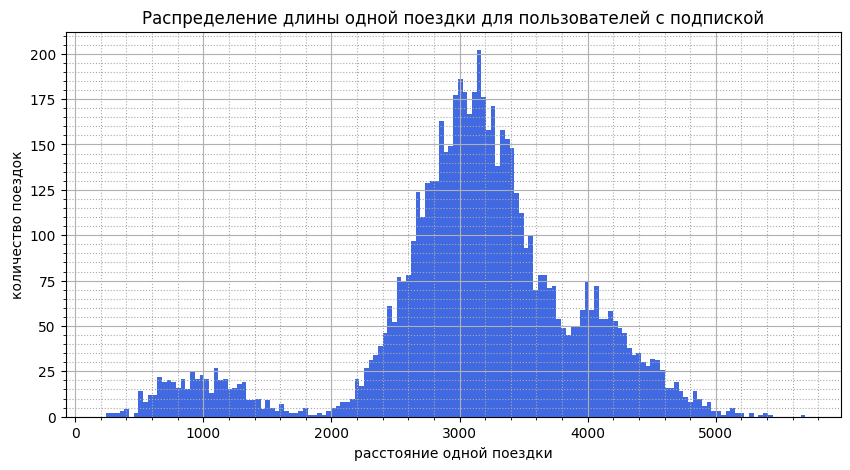

In [48]:
data_ultra['distance'].hist(bins=150,range=(200, 5700), figsize=(10,5), color='royalblue')
plt.title('Распределение длины одной поездки для пользователей с подпиской')
plt.xlabel('расстояние одной поездки')
plt.ylabel('количество поездок')
plt.minorticks_on()
plt.grid(which='minor', color='#aaa', ls=':')

In [49]:
data_ultra.query('distance <= 1800')['user_id'].count()

np.int64(502)

***Резюме:***

Для пользователей с подпиской:
- средняя длина поездки - 3,1 км
- максимальное расстояние - 5,7 км
- на графике и по срезу видно 1й "горб" с пиком поездок в районе 1 км для незначительного (502 - 7,7%) количества поездок на расстояние до 1,8 км., которое к 1,85 км. сокращается почти до 0, с последующим уже нормальным распределением количества поездок от расстояния
- 70% пользователей с подпиской осуществляют поездки на расстояние от 2,6 - 3,9 км.

#### Длительность одной поездки для пользователей с подпиской

In [50]:
data_ultra['duration'].describe(percentiles=[0.15, 0.5, 0.85])

count    6500.000000
mean       18.541985
std         5.572048
min         3.760353
15%        12.850363
50%        18.178153
85%        24.284869
max        40.823963
Name: duration, dtype: float64

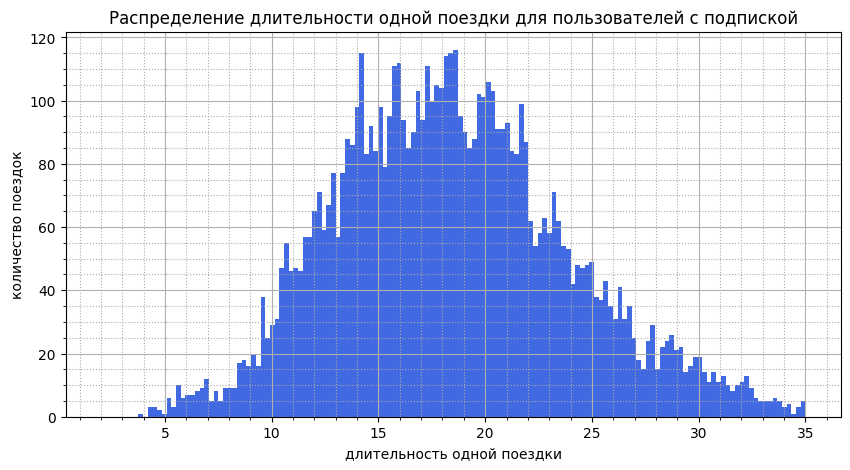

In [51]:
data_ultra['duration'].hist(bins=150,range=(2, 35), figsize=(10,5), color='royalblue')
plt.title('Распределение длительности одной поездки для пользователей c подпиской')
plt.xlabel('длительность одной поездки')
plt.ylabel('количество поездок')
plt.minorticks_on()
plt.grid(which='minor', color='#aaa', ls=':')

***Резюме:***

Для пользователей с подпиской:
- средняя длительность поездки - 19 минут
- максимальная длительность - 41 минута
- 70% поездок длится от 13 до 25 минут

### Сопоставление данных по типу подписки

Объединим распределение для обеих групп пользователей на одном графике

#### Дальность поездок пользователей с и без подписки

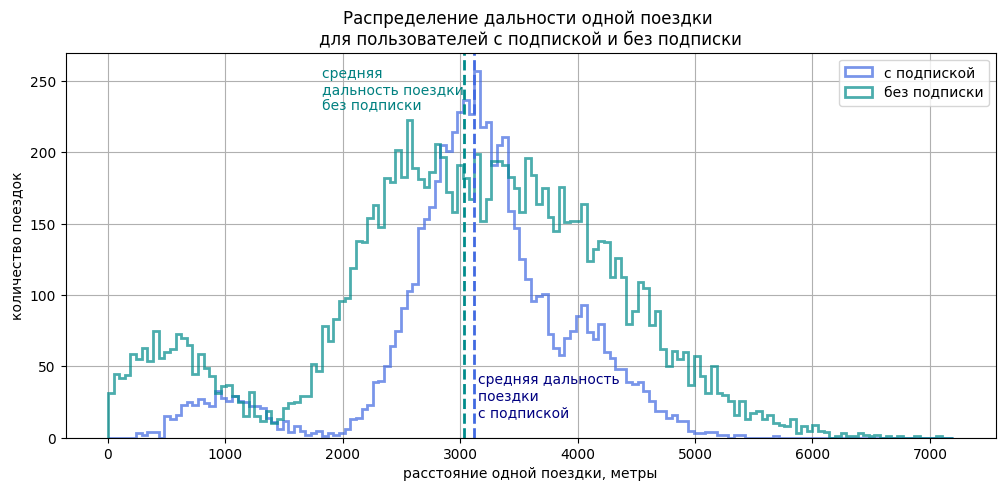

In [52]:
ax = data_ultra.plot(kind='hist', \
                     y='distance', \
                     histtype = 'step', range=(0, 7200), \
                     bins=150, linewidth=2, alpha=0.7, color='royalblue', \
                     label='с подпиской', figsize=(12, 5))
data_free.plot(kind='hist', \
                y='distance', \
                histtype = 'step', \
                range=(0, 7200), \
                bins=150, linewidth=2, alpha=0.7, color='darkcyan', \
                label='без подписки', \
                ax=ax, \
                grid=True,
                legend=True)
plt.title('Распределение дальности одной поездки \nдля пользователей c подпиской и без подписки')
plt.xlabel('расстояние одной поездки, метры')
plt.ylabel('количество поездок')
plt.axvline(x=data_ultra['distance'].mean(), color='royalblue', linewidth = 2, linestyle ="--")
plt.text(3150, 15, 'средняя дальность \nпоездки \nс подпиской', color='navy',fontsize=10)
plt.axvline(x=data_free['distance'].mean(), color='darkcyan', linewidth = 2, linestyle ="--")
plt.text(1820, 230, 'средняя \nдальность поездки \nбез подписки', color='teal',fontsize=10)
plt.show()

***Резюме:***

- График распределения количества поездок по длительности пользователей без подписки располагается выше графика пользователей с подпиской в виду того, что их доля в общем количестве пользователей превышает долю пользователей без подписки
- На графике видно, что распределение пользователей с подпиской больше сконцентрировано около среднего значения, тогда как распредление предпочтений пользователей без подписки имеет более пологий характер
- У обоих распределений видно по два пика - бимодальное распределение, у пользователей без подписки он выражено ярче. Возникло оно скорее всего из-за наличия двух типовых дальностей поездок - поездки на небольшую дистанцию около 1 км и поездки на дистанцию около 3х км

#### Сопоставим распределение длительности поездок пользователей с и без подписки

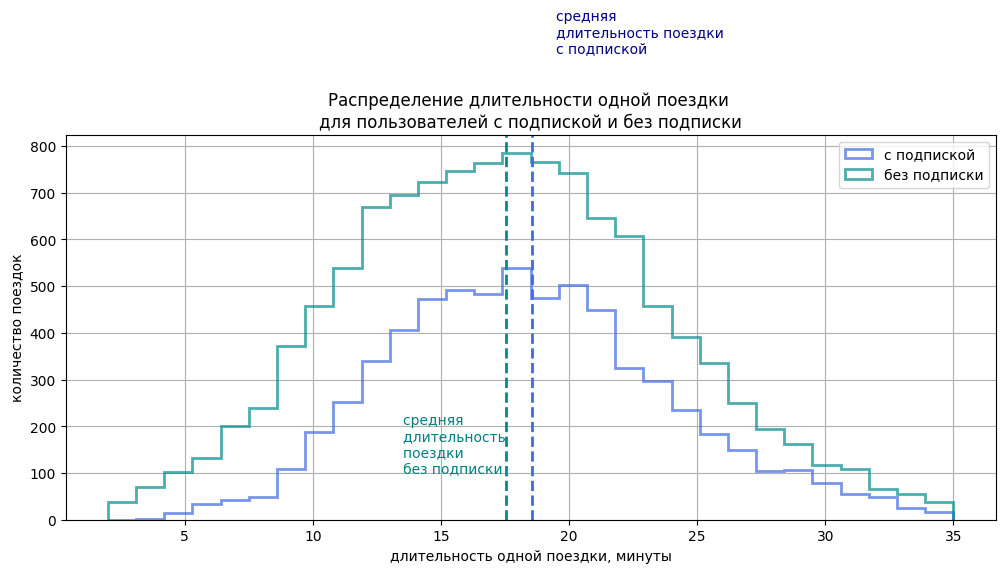

In [53]:
ax = data_ultra.plot(kind='hist', \
                     y='duration', \
                     histtype = 'step', range=(2, 35), \
                     bins=30, linewidth=2, alpha=0.7, color='royalblue', \
                     label='с подпиской', figsize=(12, 5))
data_free.plot(kind='hist', \
                y='duration', \
                histtype = 'step', \
                range=(2, 35), \
                bins=30, linewidth=2, alpha=0.7, color='darkcyan', \
                label='без подписки', \
                ax=ax, \
                grid=True,
                legend=True)
plt.title('Распределение длительности одной поездки \nдля пользователей c подпиской и без подписки')
plt.xlabel('длительность одной поездки, минуты')
plt.ylabel('количество поездок')
plt.axvline(x=data_ultra['duration'].mean(), color='royalblue', linewidth = 2, linestyle ="--")
plt.text(19.5, 1000, 'средняя \nдлительность поездки \nс подпиской', color='navy',fontsize=10)
plt.axvline(x=data_free['duration'].mean(), color='darkcyan', linewidth = 2, linestyle ="--")
plt.text(13.5, 100, 'средняя \nдлительность \nпоездки \nбез подписки', color='teal',fontsize=10)
plt.show()

***Резюме:***

- График распределения количества поездок по длительности пользователей без подписки располагается выше графика пользователей с подпиской в виду того, что их доля в общем количестве пользователей превышает долю пользователей без подписки
-  Графики распределения количества поездок по длительности пользователей без подписки и с подпиской практически повторют форму друг друга
- На обоих графиках видно достаточно большое количество поездок в районе 12.5 минут и 24 минут

## Выручка

### Анализ ежемесячной выручки от всех поездок

In [54]:
df_users = data.pivot_table(index=['user_id', 'month'], \
                            values=['duration', 'distance', 'subscription_type', \
                                    'minute_price', 'start_ride_price', 'subscription_fee'], \
                            aggfunc = ({'duration':{'count','sum'}, 
                                        'distance':'sum',
                                        'subscription_type': 'first',
                                         'minute_price': 'first',
                                         'start_ride_price':'first',
                                         'subscription_fee':'first'})).reset_index()
                             
df_users.columns = ['user_id','ride_mnth', 'mnth_distance', 'rides_amount', 'mnth_duration',\
                    'minute_price', 'start_ride_price', 'subscription_fee', 'subscription_type']
df_users['mnth_income'] = df_users['subscription_fee'] \
                        + df_users['start_ride_price'] * df_users['rides_amount'] \
                        + df_users['minute_price'] * df_users['mnth_duration']
df_users.head()                        

,user_id,ride_mnth,mnth_distance,rides_amount,mnth_duration,minute_price,start_ride_price,subscription_fee,subscription_type,mnth_income
0,1,1,7027.511294,2,41.416640,6,0,199,ultra,447.499843
1,1,4,754.159807,1,6.232113,6,0,199,ultra,236.392681
2,1,8,6723.470560,2,44.776802,6,0,199,ultra,467.660815
3,1,10,5809.911100,2,31.578017,6,0,199,ultra,388.468102
4,1,11,7003.499363,3,53.397424,6,0,199,ultra,519.384541


In [55]:
df_users['mnth_income'].describe()

count    11300.000000
mean       336.982189
std        150.626616
min         66.285060
25%        231.255926
50%        315.004577
75%        409.739606
max       1422.115405
Name: mnth_income, dtype: float64

In [56]:
df_users['mnth_distance'].describe()

count    11300.000000
mean      4866.808201
std       2883.520342
min          2.570787
25%       2964.613521
50%       3972.551070
75%       6391.866884
max      23429.487786
Name: mnth_distance, dtype: float64

In [57]:
df_users.loc[:,'ride_mnth'].mode()

0    1
Name: ride_mnth, dtype: int32

In [58]:
df_users.loc[:,'mnth_distance'].mode()

0            2.570787
1            6.784447
2           11.283615
3           15.366168
4           27.965145
             ...     
11295    21527.849820
11296    22666.615624
11297    22712.450389
11298    23098.193122
11299    23429.487786
Name: mnth_distance, Length: 11300, dtype: float64

In [59]:
df_users['mnth_income'].sum()

np.float64(3807898.731484988)

In [60]:
df_users.pivot_table(index='user_id', values='mnth_income', aggfunc='sum').mean()

mnth_income    2482.332941
dtype: float64

***Резюме:***

*Анализ данных со статистикой о ежемесячных поездках показал следующее*
- среднемесячная выручка составляет 342.3 рубля, меддианное значение отстоит незначительно и составляет 319 рублей
- в среднем пользователи в месяц преодолевают расстояние в 4.9 км, что существенно превышает медианное значение в 4.0 км., при этом наиболее часто пользователи за месяц проезжают 2.5, 2.7, 2.8, 3.3 и 3.7 км в ммесяц
- наиболее часто пользователи используют сервис в январе

*За анализируемый период - 2021 год - каждый пользователь в среднем потратил 2.5 тыс.руб, суммарно выручка сервиса для этого сегмента пользователей составила 3.9 млн рублей*

### Показатели месячной выручки по группе пользователей без подписки

In [61]:
df_users_free = df_users.query('subscription_fee == 0')
df_users_free['mnth_income'].describe()

count    6767.000000
mean      322.549772
std       179.917675
min        66.285060
25%       188.017170
50%       267.043395
75%       417.910824
max      1422.115405
Name: mnth_income, dtype: float64

In [62]:
df_users_free['mnth_distance'].describe()

count     6767.000000
mean      5134.407809
std       3161.908368
min          2.570787
25%       2934.382423
50%       4285.383529
75%       6796.612428
max      23429.487786
Name: mnth_distance, dtype: float64

In [63]:
df_users_free.loc[:,'ride_mnth'].mode()

0    1
Name: ride_mnth, dtype: int32

In [64]:
df_users_free['mnth_income'].sum()

np.float64(2182694.3101355606)

In [65]:
df_users_free.pivot_table(index='user_id', values='mnth_income', aggfunc='sum').mean()

mnth_income    2614.005162
dtype: float64

***Резюме:***

*За месяц пользователи без подписки*
- в среднем тратят 328.6 руб, при этом максимальная сумма месячных расходов - 1444.0 руб., а медианное значение - 274.0 руб.
- в среднем проезжают 5.2 км, при максимальном значении - 23.4 км, а медианном - 4.3 км.
- чаще свего поездки осуществляютс в январе

*За анализируемый период - 2021 год - каждый пользователь без подписки в среднем потратил 2.7 тыс.руб, суммарно выручка сервиса для этого сегмента пользователей составила 2.2 млн рублей*

### Показатели месячной выручки по группе пользователей с подпиской

In [66]:
df_users_ultra = df_users.query('subscription_fee == 199')
df_users_ultra['mnth_income'].describe()

count    4533.000000
mean      358.527338
std        86.391234
min       221.562117
25%       297.877820
50%       330.837832
75%       401.148080
max       937.377561
Name: mnth_income, dtype: float64

In [67]:
df_users_ultra['mnth_income'].sum()

np.float64(1625204.4213494274)

In [68]:
df_users_ultra.pivot_table(index='user_id', values='mnth_income', aggfunc='sum').mean()

mnth_income    2325.042091
dtype: float64

In [69]:
df_users_ultra['mnth_distance'].describe()

count     4533.000000
mean      4467.327382
std       2353.168174
min        244.210438
25%       2981.762521
50%       3572.518224
75%       5883.378452
max      20009.704886
Name: mnth_distance, dtype: float64

In [70]:
df_users_ultra.loc[:,'ride_mnth'].mode()

0    5
Name: ride_mnth, dtype: int32

***Резюме:***

**За месяц пользователи с подпиской**
- в среднем тратят 362.8 руб, при этом максимальная сумма месячных расходов - 955.0 руб., а медианное значение - 337.0 руб.
- в среднем проезжают 4.5 км, при максимальном значении - 20.0 км, а медианном - 3.6 км.
- чаще свего поездки осуществляютс в мае

*За анализируемый период - 2021 год - каждый пользователь без подписки в среднем потратил 2.4 тыс.руб, суммарно выручка сервиса для этого сегмента пользователей составила 1.6 млн рублей*

##  Проверка гипотез

Для проработки задачи увеличения количества пользователей с подпиской, рассмотрим ряд гипотез.


### Гипотеза 1

**Гипотеза 1** - Тратят ли пользователи с подпиской больше времени на поездки

Для проверки такой гипотезы нам необходимо провести t-тест двух независимых выборок: пользователи с подпиской и пользователи без подписки. 

- Оценим гипотезу **Ho** о том, что **средняя продолжительность поездок с подпиской и без равна** - проведем двухвыборочный t-тест с проверкой правосторонней альтернативной гипотезы с уровнем статитстической значимости равным 0,05.
-  В качестве альтернативной гипотезы **Н1** примем гипотезу, что **средняя продолжительность поездок с подпиской больше продолжительности поездок без подписок**

In [71]:
print(f'выборочное среднее для пользователей без подписки:', data_free['duration'].mean())

выборочное среднее для пользователей без подписки: 17.530771268800226


In [72]:
print(f'выборочное среднее для пользователей c подпиской:', data_ultra['duration'].mean())

выборочное среднее для пользователей c подпиской: 18.54198516280583


In [73]:
result_hypo_1 = st.ttest_ind(data_ultra['duration'], \
            data_free['duration'], \
           alternative='greater')
print(f'p-значение: {result_hypo_1.pvalue}')

alpha = 0.05
if result_hypo_1.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

p-значение: 4.7044680744539e-28
Отвергаем нулевую гипотезу


***Резюме:***

Гипотеза о том, что средняя продолжительность поездок с подпиской и без равна отвергнута. Возможно предположить, что длительность поездки пользователя с подпиской больше, чем у пользователя без подписки при установленном уровне значимости в 5 %.

### Гипотеза 2 

**Гипотеза 2** состоит в преположении, что среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров

Для проверки такой гипотезы нам необходимо провести одновыборочный левосторонний t-тест 

- Оценим гипотезу **Но** о том, что **среднее расстояние, которое проезжают пользователи с подпиской за одну поездку равно 3130 м.** - проведем правосторонний t-тест для выборки о расстоянии одной поездки пользователей с подпиской, с уровнем статитической значимости 0.05
-  В качестве альтернативной гипотезы **Н1** примем гипотезу, что **среднее расстояние поездок с подпиской больше 3130 м.**

In [74]:
print(f'выборочное среднее для пользователей с подпиской:', data_ultra['distance'].mean())

выборочное среднее для пользователей с подпиской: 3115.4453880370247


In [75]:
result_hypo_2 = st.ttest_1samp(data_ultra['distance'], 3130, alternative='greater')
print(f'p-значение: {result_hypo_2.pvalue}')

alpha = 0.05
if result_hypo_2.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

p-значение: 0.9195368847849785
Не получилось отвергнуть нулевую гипотезу


***Резюме:***

Гипотеза о том, что расстояние, которое пользователи с подпиской проезжают за одну поездку, не превышает 3130 метров не отвергается

### Гипотеза 3

**Гипотеза 3** - Будет ли месясчная выручка пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки

Для проверки такой гипотезы нам необходимо провести t-тест двух независимых выборок: месячная выручка от пользоватеей с подпиской и месячная выручка от пользователей без подписки. 

- Оценим гипотезу **Но** о том, что **среднемесячная выручка от пользователей с подпиской равна среднемесячной выручке от пользователя без подписки** - проведем правосторонний t-тест для выборки о расстоянии одной поездки пользователей с подпиской, с уровнем статитической значимости 0.05
-  В качестве альтернативной гипотезы **Н1** примем гипотезу, что **среднемесячная выручка от пользователя с подпиской больше, чем выручка от пользователя без подписки**

In [76]:
print(f'выборочное среднее для пользователей с подпиской:', df_users_free['mnth_income'].mean())

выборочное среднее для пользователей с подпиской: 322.5497724450363


In [77]:
print(f'выборочное среднее для пользователей с подпиской:', df_users_ultra['mnth_income'].mean())

выборочное среднее для пользователей с подпиской: 358.52733760190324


In [78]:
result_hypo_3 = st.ttest_ind(df_users_ultra['mnth_income'], \
            df_users_free['mnth_income'], \
            alternative='greater')
print(f'p-значение: {result_hypo_3.pvalue}')

alpha = 0.05
if result_hypo_3.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

p-значение: 4.4087200494780905e-36
Отвергаем нулевую гипотезу


***Резюме:***

Гипотеза о том, что месячная выручка от пользователя с подпиской равна выручке от пользователя без подписки отвергается. Есть вероятность, что средняя месячная выручка от пользователей с подпиской, больше средней месячной выручки от пользователей без подписки, при установленном уровне значимости в 5 %.

### Гипотеза 4

**Гипотеза 4** - После обновления сервиса, с которым взаимодействует мобильное приложение, значительно снизится количество обращений в техподдержку

Техническая команда сервиса обновила сервера, с которыми взаимодействует мобильное приложение. Команда надеется, что из-за этого количество обращений в техподдержку значимо снизилось. Некоторый файл содержит для каждого пользователя данные о количестве обращений до обновления и после него.

Для проверки Гипотезы 4 о снижении количества обращений в техподдержку в случае предоставления данных для каждого пользователя о количестве обращений до обновления и после данных, будет **необходимо провести двухвыборочный t-тест зависимых выборок**, т.к. есть файл с даннными - две зависимые выборки, и в этих данных нинформация о количестве обращений до обновления и после него, сформированных по одним и тем же пользовательям. В данном случае надо приенить метод scipy.stats.ttest_rel().

## Распределения

### Определение минимального количества промокодов

**Задача:** 
- нужно провести акцию с раздачей промокодов на один бесплатный месяц подписки, в рамках которой как минимум 100 существующих клиентов должны продлить эту подписку. То есть по завершении периода действия подписки пользователь может либо отказаться от неё, либо продлить, совершив соответствующий платёж. 
 - эта акция уже проводилась ранее и по итогу выяснилось, что **после бесплатного пробного периода подписку продлевают 10 % пользователей** 
    - **Необходимо выяснить:** 
- какое минимальное количество промокодов нужно разослать, чтобы вероятность не выполнить план была примерно 5 %. Подберите параметры распределения, описывающего эту ситуацию, постройте график распределения и сформулируйте ответ на вопрос о количестве промокодов

In [79]:
#условия задачи
n_1 = 1000 #количество наблюдений
p_1 = 0.1
a = 99 # максимальное целое число промокодов, которое эквивалентно невыполнению плана
binom_cdf = 0.05 #вероятность не вполнить план
mu_1 = n_1 * p_1 # мат.ожидание
sigma_1 = (n_1 * p_1 * (1 - p_1))**0.5 # стандартное отклонени
# подберем количество наблюдений через условный оператор while
while binom_cdf < binom.cdf(a, n_1, p_1):
    n_1 +=1
f'Необходимо разослать не менее {n_1} промокодов'

'Необходимо разослать не менее 1161 промокодов'

In [80]:
def linespace(start, stop, num):
    step = int((stop - start) / (num - 1))
    result = []
    for i in range(num):
        result.append(start + step*i)
    return result

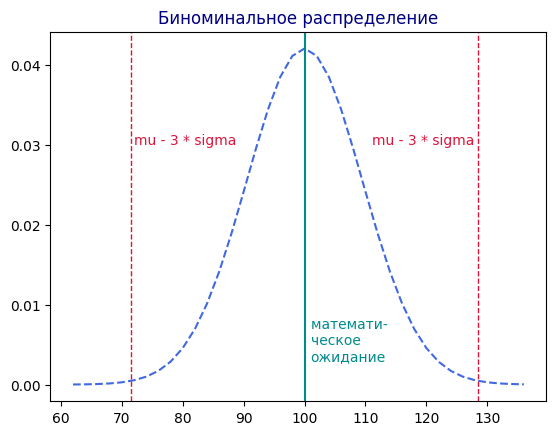

In [81]:
distr_1 = linespace(int(mu_1 - 4 * sigma_1), int(mu_1 + 4 * sigma_1), int(4 * sigma_1 + 1))

plt.plot(distr_1, st.norm.pdf(distr_1, mu_1, sigma_1), '--', color='royalblue')
plt.title('Биноминальное распределение', color='navy')
plt.axvline(x=mu_1, color='darkcyan')
plt.text(101, 0.003, 'математи- \nческое \nожидание', color='darkcyan')
plt.axvline(x=(mu_1-3*sigma_1), color='crimson', linewidth = 1, linestyle ="--")
plt.axvline(x=(mu_1+3*sigma_1), color='crimson', linewidth = 1, linestyle ="--")
plt.text(72, 0.030, 'mu - 3 * sigma', color='crimson')
plt.text(111, 0.03, 'mu - 3 * sigma', color='crimson')
plt.show()

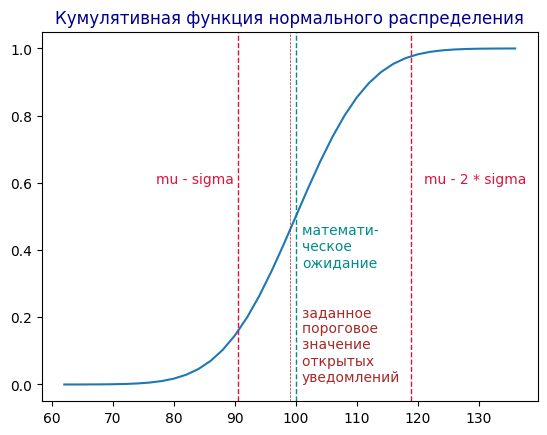

In [82]:

# создаем массив данных в пределах мат.ожидания +- 3 стандартных отклонения с равномерно распред.значениями
distr_1 = linespace(int(mu_1 - 4 * sigma_1), int(mu_1 + 4 * sigma_1), int(4 * sigma_1 + 1))

# строим кумулятивную функцию норм. распределения созданного массива
plt.plot(distr_1, norm.cdf(distr_1, mu_1, sigma_1), '-')
plt.color='royalblue'
plt.title('Кумулятивная функция нормального распределения', color='darkblue')
plt.axvline(x=(mu_1-sigma_1), color='crimson', linewidth = 1, linestyle ="--")
plt.axvline(x=(mu_1+2*sigma_1), color='crimson', linewidth = 1, linestyle ="--")
plt.text(77, 0.6, 'mu - sigma', color='crimson')
plt.text(121, 0.6, 'mu - 2 * sigma', color='crimson')
plt.axvline(x=mu_1, color='darkcyan', linewidth = 1, linestyle ="--")
plt.text(101, 0.35, 'математи- \nческое \nожидание', color='darkcyan')
plt.axvline(x=a, color='brown', linewidth = 0.5, linestyle ="--")
plt.text(101, 0.01, 'заданное \nпороговое \nзначение \nоткрытых \nуведомлений', color='brown')
plt.show()

***Резюме:***

Минимальное количество промокодов, которое необходимо разослать, чтобы вероятность не выполнить план (100 пользователей продлевают подписку) была примерно 5% составляет 1161 уведомление.

### Вероятность открытого push-уведомления

Отдел маркетинга рассылает клиентам push-уведомления в мобильном приложении. Клиенты могут открыть его или не открывать. Известно, что уведомления открывают около 40 % получивших клиентов. Отдел планирует разослать 1 млн уведомлений. С помощью аппроксимации постройте примерный график распределения и оцените вероятность того, что уведомление откроют не более 399,5 тыс. пользователей.
Подсказка
Эта ситуация тоже описывается биномиальным распределением. Но считать каждое отдельное значение достаточно долго. Вы можете воспользоваться нормальной аппроксимацией биномиального распределения и cdf() для быстрой оценки.


In [83]:
n_2 = 1000000
p_2 = 0.4
mu_2 = n_2 * p_2 # мат.ожидание
sigma_2 = sqrt(n_2 * p_2 * (1 - p_2)) # стандартное отклонение
distr_2 = st.norm(mu_2, sigma_2)
result_2 = distr_2.cdf(399500)
f'Вероятность того, что будет push_уведомление будет открыто не более чем 399,5 тыс. пользователями - {result_2.round(3)*100} %'

'Вероятность того, что будет push_уведомление будет открыто не более чем 399,5 тыс. пользователями - 15.4 %'

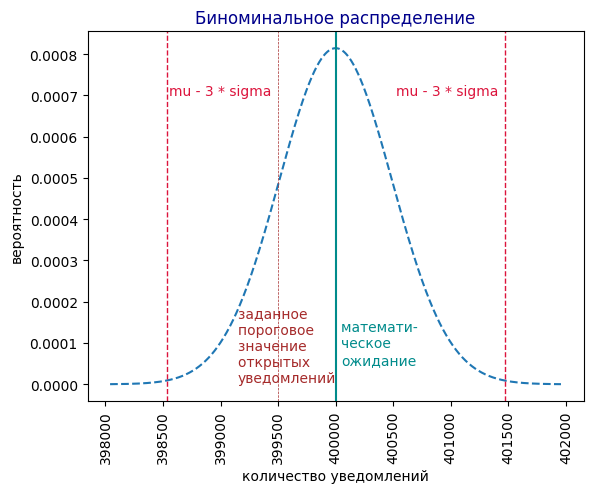

In [84]:
distr_2 = linespace(int(mu_2 - 4 * sigma_2), int(mu_2 + 4 * sigma_2), int(4 * sigma_2 + 1))

plt.plot(distr_2, st.norm.pdf(distr_2, mu_2, sigma_2), '--')
plt.color='royalblue'
plt.title('Биноминальное распределение', color='darkblue')
plt.xlabel('количество уведомлений')
plt.ylabel('вероятность')
plt.xticks(rotation=90)
plt.axvline(x=(mu_2-3*sigma_2), color='crimson', linewidth = 1, linestyle ="--")
plt.axvline(x=(mu_2+3*sigma_2), color='crimson', linewidth = 1, linestyle ="--")
plt.text(398555, 0.0007, 'mu - 3 * sigma', color='crimson')
plt.text(400525, 0.0007, 'mu - 3 * sigma', color='crimson')
plt.axvline(x=mu_2, color='darkcyan')
plt.text(400045, 0.00005, 'математи- \nческое \nожидание', color='darkcyan')
plt.axvline(x=399500, color='brown', linewidth = 0.5, linestyle ="--")
plt.text(399150, 0.000005, 'заданное \nпороговое \nзначение \nоткрытых \nуведомлений', color='brown')
plt.show()

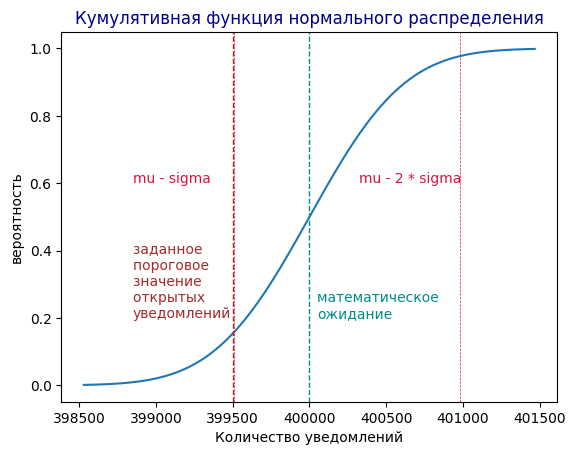

In [85]:

# создаем массив данных в пределах мат.ожидания +- 3 стандартных отклонения с равномерно распред.значениями
distr_2 = linespace(int(mu_2 - 3 * sigma_2), int(mu_2 + 3 * sigma_2), int(3 * sigma_2 + 1))

# строим кумулятивную функцию норм. распределения созданного массива
plt.plot(distr_2, norm.cdf(distr_2, mu_2, sigma_2), '-')
plt.color='royalblue'
plt.title('Кумулятивная функция нормального распределения', color='darkblue')
plt.xlabel('Количество уведомлений')
plt.ylabel('вероятность')
plt.axvline(x=399500, color='brown', linewidth = 1, linestyle ="--")
plt.text(398850, 0.2, 'заданное \nпороговое \nзначение \nоткрытых \nуведомлений', color='brown')
plt.text(398850, 0.6, 'mu - sigma', color='crimson')
plt.text(400325, 0.6, 'mu - 2 * sigma', color='crimson')
plt.axvline(x=(mu_2 - sigma_2), color='crimson', linewidth = 0.5, linestyle ="--")
plt.axvline(x=(mu_2 + 2 * sigma_2), color='crimson', linewidth = 0.5, linestyle ="--")
plt.axvline(x=mu_2, color='darkcyan', linewidth = 1, linestyle ="--")
plt.text(400050, 0.2, 'математическое \nожидание', color='darkcyan')
plt.show()

***Резюме:*** 

Если разослать 1 млн уведомлений и откроют уведомлмения только 40 % получивших клиентов, то вероятность того, что уведомление откроют не более 399,5 тыс. пользователей составляет 15,4%

## Общий вывод по проекту

### Исходные данные

Для анализа информации о пользователях, их поездках и подписках предоставлено три дата-сета
 - данные о пользователях (id, имя, возраст, город и тип подписки) - 1565 записей(по количчесвту пользователей), пропусков в данных нет
 - данные о поездках (id, дистанция, длительность и дата поездки) - 18068 запией (по количеству поездок), пропусков в данных нет
 - информация о подписках (тип подписки, стоимость минуты поездки, стоимость старта и размер ежемесячного платежа) - 2 записи (2 типа подписки), пропусков в данных нет

### Подготовка данных

На этапе подготовки данных
- выявлены и удалены 31 запись-дубликат в данных о пользователях, в оставшихся дата-сетах дубликаты не выявлены;
- изменен формат данных о дате поездки - приведен к формату - datetime;
- создана дополнительная аналитика date_month - месяц поездки
- объединена информация о пользователях, их поездках и тарифах
- после объединения информации проведена повторная проверка на дубликат по группе аналитик (дата, длительность, дальность поездкии город пользователя) - дубликаты не выявлены

### Исследовательский анализ данных

Детализированный анализ данных о поездках, 
1. сгруппированных по городам показал, что 
      - всего данные содержат информацию о пользователях из 8 городов
      - больше всего пользователей в Пятигорске - 219 пользвателей, а меньше всего - в Москве - 168
      - больше всего поездок осуществляется в Пятигорске - 2524 поездки, где также и самая большая средняя дистанция одной поездки - 3118,68 м.
      - меньше всего поездок в Москве - 1875 поездки
      - в среднем самые короткие поездки - в Ростове-на-Дону - 3011,51 м.
      - средняя длительность поездок различается по городам на десятые доли секунд
2. сгруппированных по возрасту пользователей показал, что
      - средний и медианный возраст пользователей практически совпадает и составляет 25 лет
      - 70% пользователей - пользователи в возрасте от 20 до 30 лет
      - среди этой категории 66,5% не пользуются подпиской
3. сгруппированных по расстоянию одной поездки показал, что  
    - 70% поездок осуществляется на расстояние от 2,1 до 4,2 км.,
    - медианное значение составляет 3,1 км.
    - максимальная длина одной поездки составляет 7,2 км.
4. сгруппированных по продолжительности одной поездки показал, что
    - незначительный выброс - 0,05% - поездки длительностью менее 1 минуты, записи о которых были удалены 
    - после удаления 95 записей статистика поездок отражает, что 
         - 70% поездок длится от 12 до 25 минут 
         - медианное значение составляет 18 минут
         - минимальная длительность поездки - 2 минуты
         - максимальная длительность поездки - 41 минута
5. сгруппированных по типу подписки показал, что   
    - Для пользователей без подписки:
        - средняя длина поездки - 3,1 км
        - максимальное расстояние - 7,1 км
        - 70% пользователей без подписки совершают поездки на расстояние от 1,9 до 4,3 км.
        - средняя длительность поездки - 18 минут
        - максимальная длительность - 35 минут
        - 70% поездок длится от 12 до 24 минут
    - Для пользователей с подпиской:
        - средняя длина поездки - 3,1 км
        - максимальное расстояние - 5,7 км
        - на графике и по срезу видно 1й "горб" с пиком поездок в районе 1 км для незначительного (502 - 7,7%) количества поездок на расстояние до 1,8 км., которое к 1,85 км. сокращается почти до 0, с последующим уже нормальным распределением количества поездок от расстояния
        - 70% пользователей с подпиской осуществляют поездки на расстояние от 2,6 - 3,9 км.  
        - средняя длительность поездки - 19 минут
        - максимальная длительность - 41 минута
        - 70% поездок длится от 12 до 25 минут

### Анализ выручки сервиса

- за анализируемый период - 2021 год 
    - ***каждый пользователь в среднем потратил 2.5 тыс.руб***, суммарно выручка сервиса для этого сегмента пользователей составила 3.9 млн рублей
    - ***каждый пользователь без подписки в среднем потратил 2.7 тыс.руб***, суммарно выручка сервиса для этого сегмента пользователей составила 2.2 млн рублей
    - ***каждый пользователь без подписки в среднем потратил 2.4 тыс.руб***, суммарно выручка сервиса для этого сегмента пользователей составила 1.6 млн рублей
- среднемесячная выручка от всех поездок составляет 342.3 рубля, меддианное значение отстоит незначительно и составляет 319 рублей
- в среднем пользователи в месяц преодолевают расстояние в 4.9 км, что существенно превышает медианное значение в 4.0 км., при этом наиболее часто пользователи за месяц проезжают 2.5, 2.7, 2.8, 3.3 и 3.7 км в ммесяц
- наиболее часто пользователи используют сервис в январе
- за месяц пользователи без подписки
    - в среднем тратят 328.6 руб, при этом максимальная сумма месячных расходов - 1444.0 руб., а медианное значение - 274.0 руб.
    - в среднем проезжают 5.2 км, при максимальном значении - 23.4 км, а медианном - 4.3 км.
    - чаще свего поездки осуществляютс в январе
- за месяц пользователи с подпиской
    - в среднем тратят 362.8 руб, при этом максимальная сумма месячных расходов - 955.0 руб., а медианное значение - 337.0 руб.
    - в среднем проезжают 4.5 км, при максимальном значении - 20.0 км, а медианном - 3.6 км.
    - чаще свего поездки осуществляютс в мае

###  Проверка гипотез

- Гипотеза 1  о том, что средняя продолжительность поездок с подпиской и без равна отвергнута. Возможно предположить, что длительность поездки пользователя с подпиской больше, чем у пользователя без подписки при установленном уровне значимости в 5 %.
- Гипотеза 2 о том, что расстояние, которое пользователи с подпиской проезжают за одну поездку, не превышает 3130 метров не отвергается: среднее расстояние поездки, пользователей с подпиской, не превышает оптимальное с точки зрения износа самоката расстоянием в 3130 метров, при установленном уровне значимости в 5 %.
- Гипотеза 3 о том, что месячная выручка от пользователя с подпиской равна среднемесяной выручке от пользователя без подписки отвергается. Возможно предположить, что  среднемесячная выручка от пользователя с подпиской, больше среднемесячной выручки от пользователя без подписки, при установленном уровне значимости в 5 %.
- Для проверки Гипотезы 4 о снижении количества обращений в техподдержку в случае предоставления данных для каждого пользователя о количестве обращений до обновления и после данных, будет необходимо провести двухвыборочный t-тест зависимых выборок

### Распределение

В ходе анализа распределений было определено:
1. Минимальное количество промокодов, которое необходимо разослать, чтобы вероятность не выполнить план (100 пользователей продлевают подписку) была примерно 5% составляет 1161 уведомление.
2. Если разослать 1 млн уведомлений и откроют уведомлмения только 40 % получивших клиентов, то вероятность того, что уведомление откроют не более 399,5 тыс. пользователей составляет 15,4%